In [1]:
from typing import Any, Dict
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import rlenvs
import pandas as pd


from pmbrl.model2 import Model, Transition_Estimator, Reward_Estimator_Base
from pmbrl.data import Experiment_Data

In [2]:
data = Experiment_Data()
data.generate_episodes(10)
data.build_training_dataset()
x, y = data.get_features_targets()

data.raw_data.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,s,a,r,s_,p,episode
0,0,"[0.021, -0.035, 0.009, -0.003]",1,1.0,"[0.02, 0.154, 0.009, -0.17]","(0.28, 1.0)",0
1,1,"[0.02, 0.154, 0.009, -0.17]",1,1.0,"[0.023, 0.344, 0.005, -0.337]","(0.28, 1.0)",0
2,2,"[0.023, 0.344, 0.005, -0.337]",1,1.0,"[0.03, 0.533, -0.001, -0.505]","(0.28, 1.0)",0
3,3,"[0.03, 0.533, -0.001, -0.505]",1,1.0,"[0.041, 0.723, -0.012, -0.674]","(0.28, 1.0)",0
4,4,"[0.041, 0.723, -0.012, -0.674]",0,1.0,"[0.055, 0.533, -0.025, -0.507]","(0.28, 1.0)",0


In [3]:
model = Model()

trainer = model.train(x, y, num_epochs=10)
data.get_training_data(trainer)
data.training_data.head()

,epoch,s,p,r
0,0,"[-0.1869061440229416, 0.0720171332359314, -0.2...","[0.14426392316818237, -0.2261122763156891]",[0.3929726779460907]
0,0,"[-0.24549007415771484, -0.05227106809616089, -...","[0.12318646907806396, -0.22998568415641785]",[0.3994804918766022]
0,0,"[0.006480947136878967, 0.5095869302749634, -0....","[0.06994377076625824, -0.22053812444210052]",[0.37937647104263306]
0,0,"[-0.1541217863559723, 0.031904518604278564, -0...","[0.10594666004180908, -0.28199058771133423]",[0.40569379925727844]
0,0,"[-0.31502825021743774, -0.18458521366119385, -...","[0.1643103063106537, -0.24897949397563934]",[0.40091586112976074]


In [4]:
results = data.evaluate_model(model, n_episodes=3)
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_p,estimated_r
0,0,0,"(0.74, 1.8)","[0.016, -0.049, -0.026, -0.008]",0,1.0,"[0.015, -0.237, -0.026, 0.14]",0.0,1.0,"[0.01, -0.426, -0.023, 0.289]","[-0.161, 0.059, -0.183, -0.222]","(0.12, -0.23)",0.4
1,1,0,"(0.74, 1.8)","[0.015, -0.237, -0.026, 0.14]",0,1.0,"[0.01, -0.426, -0.023, 0.289]",0.0,1.0,"[0.002, -0.614, -0.018, 0.438]","[-0.208, -0.017, -0.216, -0.217]","(0.12, -0.24)",0.4
2,2,0,"(0.74, 1.8)","[0.01, -0.426, -0.023, 0.289]",0,1.0,"[0.002, -0.614, -0.018, 0.438]",1.0,1.0,"[-0.011, -0.425, -0.009, 0.282]","[-0.108, -0.114, -0.145, -0.248]","(0.12, -0.24)",0.4
3,3,0,"(0.74, 1.8)","[0.002, -0.614, -0.018, 0.438]",1,1.0,"[-0.011, -0.425, -0.009, 0.282]",0.0,1.0,"[-0.019, -0.614, -0.003, 0.433]","[-0.204, -0.039, -0.215, -0.218]","(0.04, -0.31)",0.4
4,4,0,"(0.74, 1.8)","[-0.011, -0.425, -0.009, 0.282]",0,1.0,"[-0.019, -0.614, -0.003, 0.433]",1.0,1.0,"[-0.031, -0.425, 0.005, 0.28]","[-0.107, -0.118, -0.142, -0.245]","(0.11, -0.24)",0.4


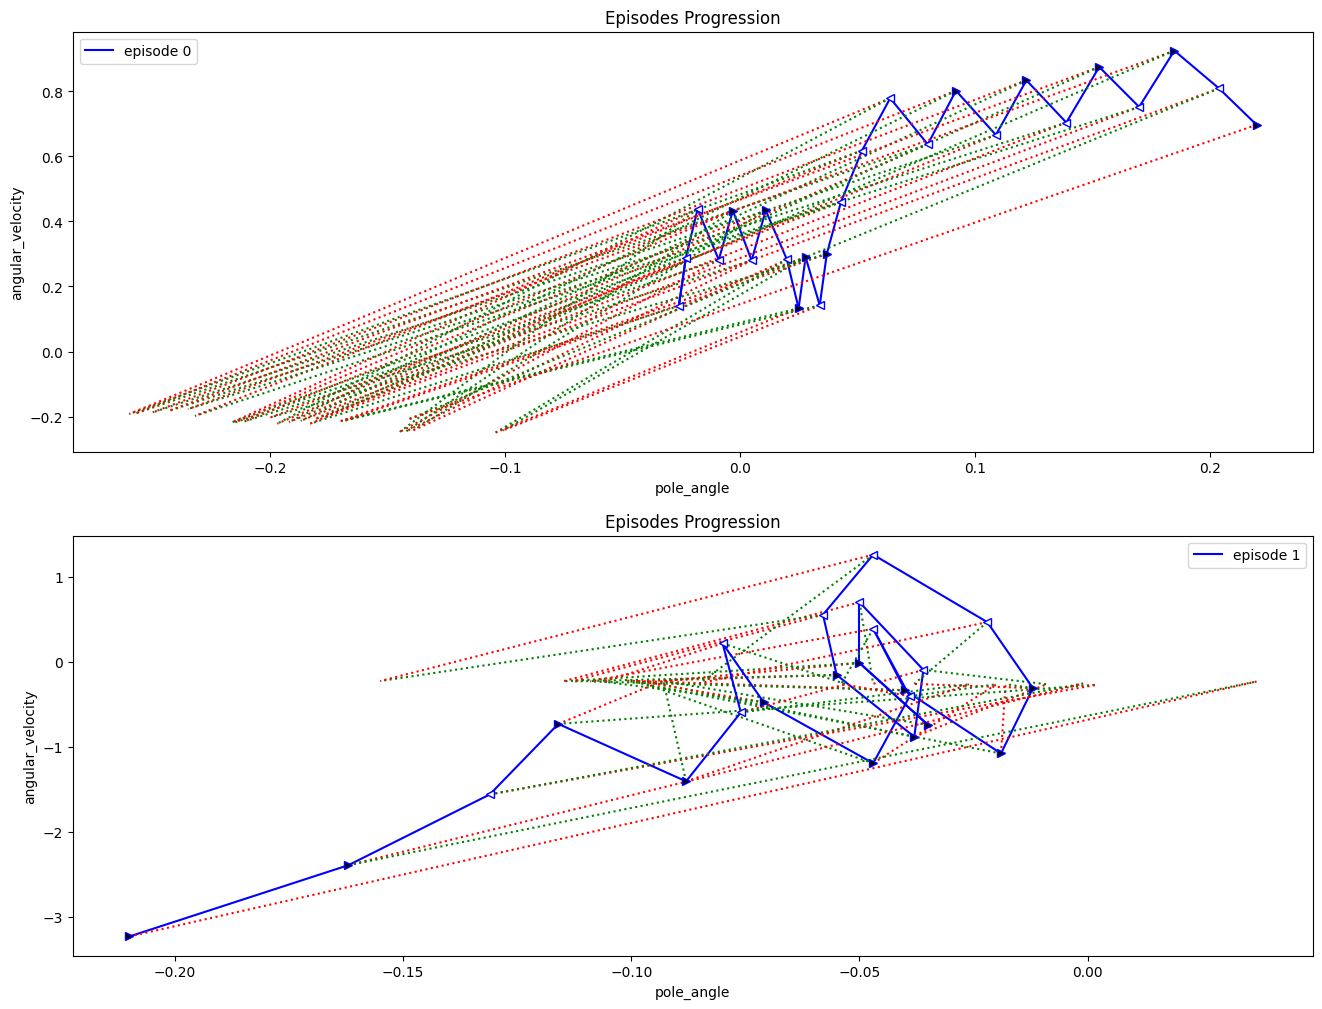

In [5]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
plt.show()